# Лабораторная работа: Кластеризация и снижение размерности (Digits)
**Выполнил:** Медведь Е.Ю. ИСУ 368509
**Дисциплина:** Методы искусственного интеллекта  
**Датасет:** `sklearn.datasets.load_digits()` (8×8 пикселей - 64 признака, 10 классов). Он содержит изображения рукописных цифр 0–9 в виде матриц 8×8. Каждое изображение развёрнуто в вектор длины 64 (интенсивности пикселей). Метки классов используются только для внешней оценки кластеризации (ARI/NMI/accuracy после сопоставления), а не для обучения.
Датасет используется в работе, потому что он содержит умеренно высокоразмерные числовые данные с ожидаемой скрытой структурой (цифры), допускает применение линейных и нелинейных методов снижения размерности и кластеризации, а наличие истинных меток позволяет объективно оценивать качество кластеров внешними метриками.


## 1. Данные и первичный обзор


In [ ]:
# Импорт библиотек и загрузка датасета Digits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data          # (n_samples, 64)
y = digits.target        # (n_samples,)
images = digits.images   # (n_samples, 8, 8)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("images shape:", images.shape)
print("Classes:", np.unique(y))


X shape: (1797, 64)
y shape: (1797,)
images shape: (1797, 8, 8)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# Распределение классов
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} samples")


Class 0: 178 samples
Class 1: 182 samples
Class 2: 177 samples
Class 3: 183 samples
Class 4: 181 samples
Class 5: 182 samples
Class 6: 181 samples
Class 7: 179 samples
Class 8: 174 samples
Class 9: 180 samples


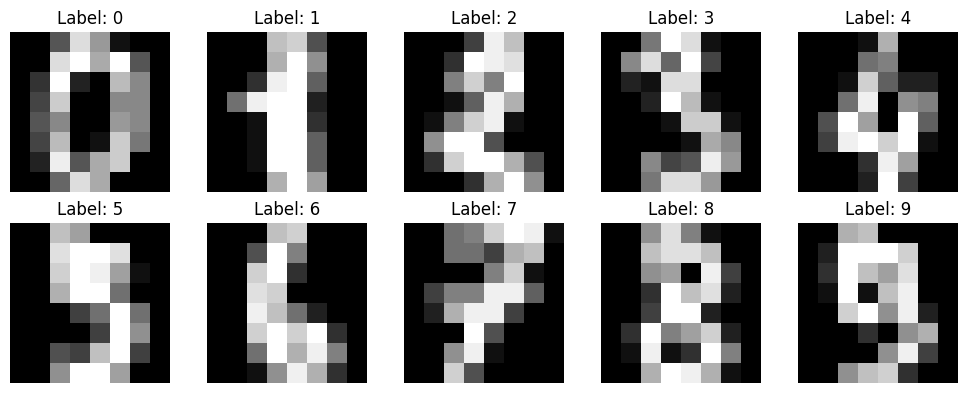

In [ ]:
# Визуализация примеров изображений
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(images[i], cmap="gray")
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 2. Подготовка и EDA


In [ ]:
# Разбиение train/test (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1437, 64) Test: (360, 64)


In [ ]:
# ML-конвейер препроцессинга: импутация + стандартизация
# Для Digits пропусков обычно нет, но SimpleImputer добавляем для универсальности пайплайна.
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_prep = preprocess.fit_transform(X_train)
X_test_prep  = preprocess.transform(X_test)

print("NaNs in X:", np.isnan(X).sum())
print("Prepared train mean =", float(X_train_prep.mean()), "std =", float(X_train_prep.std()))


NaNs in X: 0
Prepared train mean = 7.416938786639876e-18 std = 0.9762812094883324


In [ ]:
# Описательная статистика (артефакт для отчёта)
X_df = pd.DataFrame(X, columns=[f"px_{i}" for i in range(X.shape[1])])

desc = X_df.describe().T
desc["missing"] = X_df.isna().sum()
desc["missing_%"] = (desc["missing"] / len(X_df) * 100).round(3)

desc.head(10)


,count,mean,std,min,25%,50%,75%,max,missing,missing_%
px_0,1797.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0,0.0
px_1,1797.0,0.303840,0.907192,0.0,0.0,0.0,0.0,8.0,0,0.0
px_2,1797.0,5.204786,4.754826,0.0,1.0,4.0,9.0,16.0,0,0.0
px_3,1797.0,11.835838,4.248842,0.0,10.0,13.0,15.0,16.0,0,0.0
px_4,1797.0,11.848080,4.287388,0.0,10.0,13.0,15.0,16.0,0,0.0
px_5,1797.0,5.781859,5.666418,0.0,0.0,4.0,11.0,16.0,0,0.0
px_6,1797.0,1.362270,3.325775,0.0,0.0,0.0,0.0,16.0,0,0.0
px_7,1797.0,0.129661,1.037383,0.0,0.0,0.0,0.0,15.0,0,0.0
px_8,1797.0,0.005565,0.094222,0.0,0.0,0.0,0.0,2.0,0,0.0
px_9,1797.0,1.993879,3.196160,0.0,0.0,0.0,3.0,16.0,0,0.0


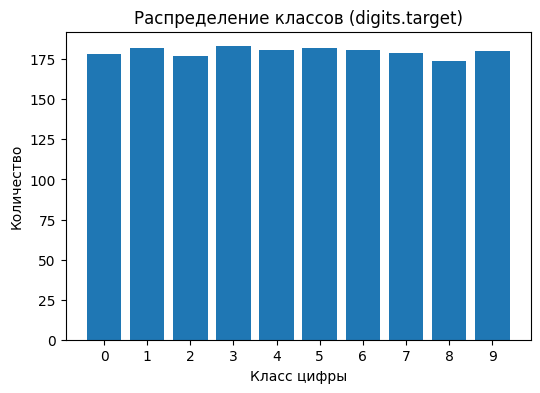

In [ ]:
# Иллюстрация 1: распределение классов
plt.figure(figsize=(6,4))
plt.bar(unique, counts)
plt.xticks(unique)
plt.title("Распределение классов (digits.target)")
plt.xlabel("Класс цифры")
plt.ylabel("Количество")
plt.show()


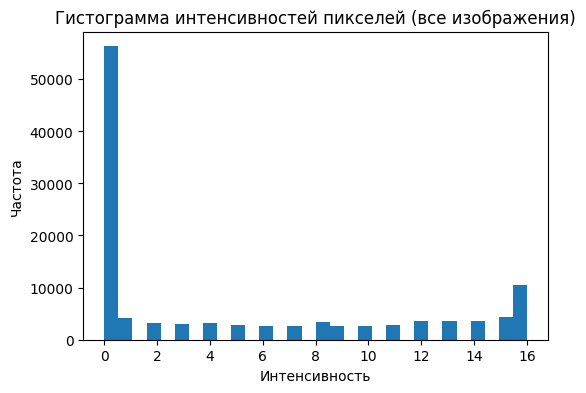

In [ ]:
# Иллюстрация 2: гистограмма интенсивностей пикселей (видна разреженность: много нулей)
plt.figure(figsize=(6,4))
plt.hist(X.ravel(), bins=30)
plt.title("Гистограмма интенсивностей пикселей (все изображения)")
plt.xlabel("Интенсивность")
plt.ylabel("Частота")
plt.show()


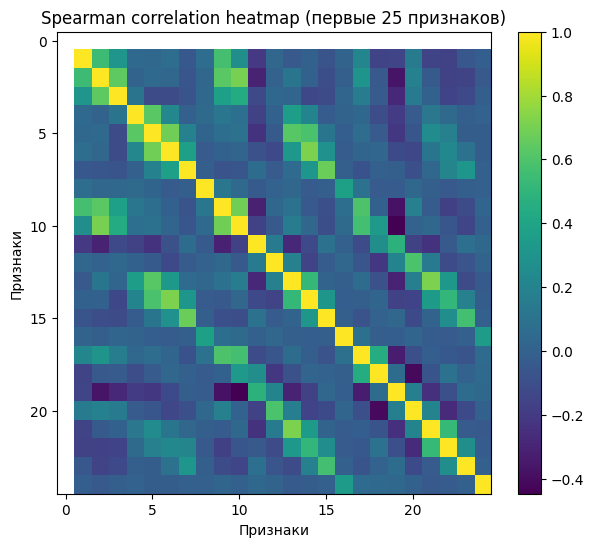

In [ ]:
# Иллюстрация 3: корреляции (Спирмен) по поднабору признаков
corr_s = X_df.corr(method="spearman")
k = 25

plt.figure(figsize=(7,6))
plt.imshow(corr_s.iloc[:k, :k].values, aspect="auto")
plt.title(f"Spearman correlation heatmap (первые {k} признаков)")
plt.colorbar()
plt.xlabel("Признаки")
plt.ylabel("Признаки")
plt.show()


In [ ]:
# Диагностика выбросов (без удаления): IsolationForest + LOF
# Влияние фиксируем через изменение explained variance PCA на "inliers".
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso.fit(X_train_prep)

iso_train_pred = iso.predict(X_train_prep)  # +1 inlier, -1 outlier
iso_test_pred  = iso.predict(X_test_prep)

print("IsolationForest outlier rate: train =", (iso_train_pred == -1).mean(),
      "test =", (iso_test_pred == -1).mean())

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True)
lof.fit(X_train_prep)
lof_train_pred = lof.predict(X_train_prep)
lof_test_pred  = lof.predict(X_test_prep)

print("LOF outlier rate: train =", (lof_train_pred == -1).mean(),
      "test =", (lof_test_pred == -1).mean())

# "Влияние" на PCA: сравнение sum explained variance на всех vs inliers
pca_all = PCA(n_components=20, random_state=42).fit(X_train_prep)
pca_in  = PCA(n_components=20, random_state=42).fit(X_train_prep[iso_train_pred == 1])

print("PCA explained variance ratio sum (20 comps):")
print("  all    =", pca_all.explained_variance_ratio_.sum())
print("  inlier =", pca_in.explained_variance_ratio_.sum())


IsolationForest outlier rate: train = 0.05010438413361169 test = 0.06388888888888888
LOF outlier rate: train = 0.04036186499652053 test = 0.06111111111111111
PCA explained variance ratio sum (20 comps):
  all    = 0.7898940529296021
  inlier = 0.8089250539027888


**Гипотезы о структуре данных (по EDA):**
1. В данных присутствует нелинейная многообразная структура (вариативность написания цифр) - нелинейные методы (t-SNE) должны лучше раскрывать кластеры.
2. Кластеры существуют, но частично перекрываются и не обязаны строго совпадать с 10 классами (возможны разные «стили» одной цифры).
3. Есть небольшая доля аномальных/пограничных примеров, которые размывают структуру и ухудшают чёткость кластеров.


## 3. Снижение размерности: PCA и t-SNE


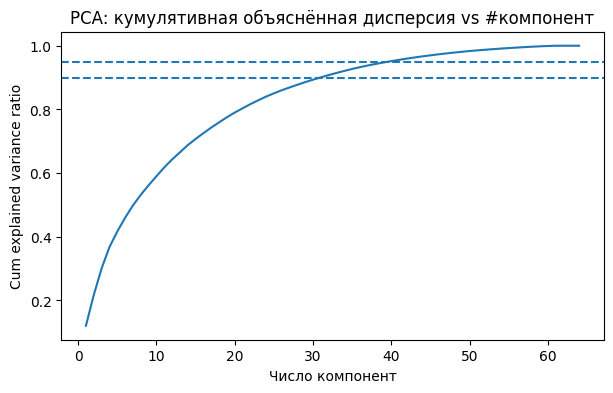

k for 90%: 31 | k for 95%: 40


In [ ]:
# PCA: explained variance vs число компонент + выбор k по 90% и 95%
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA(random_state=42).fit(X_train_prep)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(cum)+1), cum)
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.title("PCA: кумулятивная объяснённая дисперсия vs #компонент")
plt.xlabel("Число компонент")
plt.ylabel("Cum explained variance ratio")
plt.show()

k_90 = int(np.searchsorted(cum, 0.90) + 1)
k_95 = int(np.searchsorted(cum, 0.95) + 1)
print("k for 90%:", k_90, "| k for 95%:", k_95)


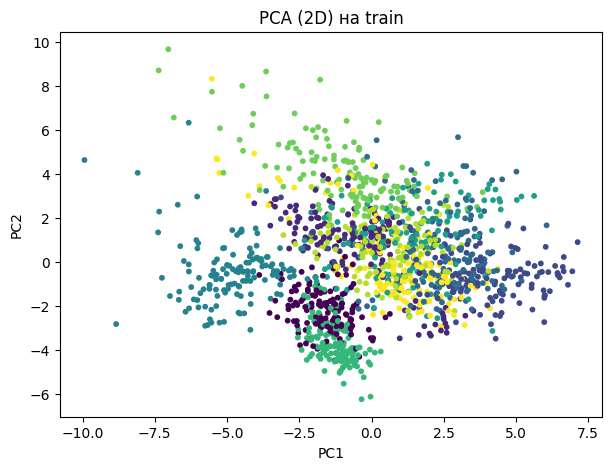

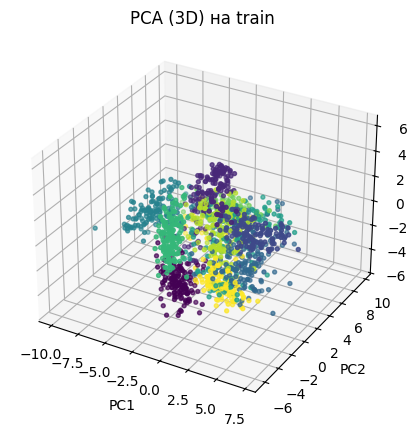

In [ ]:
# Визуализация PCA в 2D и 3D (по train)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_train_prep)

plt.figure(figsize=(7,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=y_train, s=10)
plt.title("PCA (2D) на train")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_train_prep)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y_train, s=8)
ax.set_title("PCA (3D) на train")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
plt.show()


In [ ]:
# t-SNE: подбор perplexity + устойчивость (5 запусков с разными random_state)
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import time
import pandas as pd

# Предсжатие PCA перед t-SNE - для ускорения и подавления шума
X_train_40 = PCA(n_components=40, random_state=42).fit_transform(X_train_prep)

perplexities = [5, 20, 30, 50]
seeds = [0, 1, 2, 3, 4]

rows = []
for perp in perplexities:
    for seed in seeds:
        tsne = TSNE(n_components=2, perplexity=perp, learning_rate="auto", init="pca", random_state=seed)
        t0 = time.perf_counter()
        X_tsne = tsne.fit_transform(X_train_40)
        t_tsne = time.perf_counter() - t0

        labels = KMeans(n_clusters=10, n_init=20, random_state=42).fit_predict(X_tsne)
        sil = silhouette_score(X_tsne, labels)
        ari = adjusted_rand_score(y_train, labels)
        nmi = normalized_mutual_info_score(y_train, labels)

        rows.append([perp, seed, t_tsne, sil, ari, nmi])

tsne_table = pd.DataFrame(rows, columns=["perplexity","seed","time_sec","silhouette","ARI","NMI"])
tsne_summary = (tsne_table.groupby("perplexity")[["time_sec","silhouette","ARI","NMI"]]
                .agg(["mean","std"]).reset_index())
tsne_summary


perplexity   time_sec           silhouette                 ARI            \
                   mean       std       mean       std      mean       std   
0          5  10.192862  2.160703   0.488131  0.003316  0.738413  0.009790   
1         20  10.814094  0.213938   0.589756  0.000717  0.816746  0.000634   
2         30  11.905716  0.605232   0.589163  0.000838  0.825562  0.006245   
3         50  13.536246  0.198107   0.556187  0.000946  0.760417  0.008514   

        NMI            
       mean       std  
0  0.810992  0.006039  
1  0.867505  0.000805  
2  0.859040  0.002679  
3  0.824680  0.003118

## 4. Кластеризация: KMeans и DBSCAN (+ устойчивость)


In [ ]:
# Вспомогательные функции метрик и Hungarian matching (accuracy после сопоставления)
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

def hungarian_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    classes = np.unique(y_true)
    clusters = np.unique(y_pred)

    cont = np.zeros((len(classes), len(clusters)), dtype=np.int64)
    for i, c in enumerate(classes):
        for j, k in enumerate(clusters):
            cont[i, j] = np.sum((y_true == c) & (y_pred == k))

    r, c = linear_sum_assignment(-cont)
    return cont[r, c].sum() / len(y_true)

def report_metrics(X, labels, y_true=None):
    labels = np.asarray(labels)
    mask = labels != -1
    uniq = np.unique(labels[mask]) if np.any(mask) else np.array([])

    out = {
        "n_clusters": int(len(uniq)),
        "noise_rate": float(np.mean(labels == -1)),
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
        "ARI": np.nan,
        "NMI": np.nan,
        "hungarian_acc": np.nan,
    }

    if len(uniq) >= 2 and np.sum(mask) > len(uniq):
        out["silhouette"] = float(silhouette_score(X[mask], labels[mask]))
        out["calinski_harabasz"] = float(calinski_harabasz_score(X[mask], labels[mask]))
        out["davies_bouldin"] = float(davies_bouldin_score(X[mask], labels[mask]))

    if y_true is not None:
        out["ARI"] = float(adjusted_rand_score(y_true, labels))
        out["NMI"] = float(normalized_mutual_info_score(y_true, labels))
        if not np.any(labels == -1):
            out["hungarian_acc"] = float(hungarian_accuracy(y_true, labels))
    return out


In [ ]:
# Подготовка пространств: RAW(64D), PCA(40D), t-SNE(2D)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X0 = X_train_prep
y0 = y_train

X_pca40 = PCA(n_components=40, random_state=42).fit_transform(X0)

# t-SNE берём с лучшим perplexity=20 (по результатам п.3) и фиксируем seed
tsne = TSNE(n_components=2, perplexity=20, learning_rate="auto", init="pca", random_state=0)
t0 = time.perf_counter()
X_tsne2 = tsne.fit_transform(X_pca40)
print("t-SNE time:", time.perf_counter() - t0)


t-SNE time: 10.656309403000023


In [ ]:
# KMeans: подбор k по внутренним метрикам (silhouette/CH/DB) в PCA(40D)
k_range = range(2, 21)
rows = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    t0 = time.perf_counter()
    labels = km.fit_predict(X_pca40)
    t = time.perf_counter() - t0
    m = report_metrics(X_pca40, labels, y_true=y0)
    rows.append({"k": k, "time_sec": t, "inertia": float(km.inertia_), **m})

kmeans_scan = pd.DataFrame(rows)
kmeans_scan.sort_values("silhouette", ascending=False).head(5)


,k,time_sec,inertia,n_clusters,noise_rate,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,hungarian_acc
18,20,0.262019,38083.101203,20,0.0,0.172558,88.765422,1.435916,0.628720,0.730636,0.725122
17,19,0.280067,38958.328232,19,0.0,0.172104,89.886705,1.485685,0.604165,0.712997,0.699374
12,14,0.213749,44036.611977,14,0.0,0.171249,97.871195,1.392528,0.536326,0.682349,0.663187
10,12,0.236708,47286.083164,12,0.0,0.170277,98.966572,1.598938,0.542748,0.684967,0.663187
14,16,0.252925,42185.290237,16,0.0,0.170074,92.577115,1.551463,0.596230,0.703491,0.682672


In [ ]:
# Выбираем k по максимуму silhouette (как автоматический критерий)
best_row = kmeans_scan.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).iloc[0]
k_best = int(best_row["k"])
print("Best k by silhouette:", k_best)
best_row[["k","silhouette","ARI","NMI","hungarian_acc","time_sec"]]


Best k by silhouette: 20


,18
k,20.000000
silhouette,0.172558
ARI,0.628720
NMI,0.730636
hungarian_acc,0.725122
time_sec,0.262019


In [ ]:
# Финальный KMeans в выбранном пространстве (PCA-40D), отчёт метрик в трёх пространствах
km_final = KMeans(n_clusters=k_best, n_init=20, random_state=42)
t0 = time.perf_counter()
labels_km = km_final.fit_predict(X_pca40)
t_km = time.perf_counter() - t0

km_report = pd.DataFrame([
    {"space_eval": "RAW(64D)", **report_metrics(X0, labels_km, y_true=y0)},
    {"space_eval": "PCA(40D)", **report_metrics(X_pca40, labels_km, y_true=y0)},
    {"space_eval": "t-SNE(2D)", **report_metrics(X_tsne2, labels_km, y_true=y0)},
])
print("KMeans fit time:", t_km, "sec")
km_report


KMeans fit time: 0.24542231200001652 sec


,space_eval,n_clusters,noise_rate,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,hungarian_acc
0,RAW(64D),20,0.0,0.157418,80.266910,1.517949,0.62872,0.730636,0.725122
1,PCA(40D),20,0.0,0.172558,88.765422,1.435916,0.62872,0.730636,0.725122
2,t-SNE(2D),20,0.0,0.252036,742.115723,1.039231,0.62872,0.730636,0.725122


In [ ]:
# DBSCAN: grid-search eps×min_samples (лучшее сравниваем в RAW и PCA)
from sklearn.cluster import DBSCAN

eps_pca = np.linspace(1.0, 6.0, 11)
min_samples_grid = [3, 5, 10, 15, 20]

rows = []
for eps in eps_pca:
    for ms in min_samples_grid:
        db = DBSCAN(eps=float(eps), min_samples=int(ms), n_jobs=-1)
        t0 = time.perf_counter()
        labels = db.fit_predict(X_pca40)
        t = time.perf_counter() - t0
        m = report_metrics(X_pca40, labels, y_true=y0)
        rows.append({"eps": float(eps), "min_samples": int(ms), "time_sec": t, **m})

dbscan_scan = pd.DataFrame(rows)
dbscan_scan.sort_values("silhouette", ascending=False).head(10)


,eps,min_samples,time_sec,n_clusters,noise_rate,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,hungarian_acc
10,2.0,3,0.015028,6,0.971468,0.610270,56.094757,0.601053,0.001146,0.054203,NaN
22,3.0,10,0.022284,4,0.895616,0.457737,151.893180,0.922654,0.014857,0.184944,NaN
29,3.5,20,0.022656,3,0.845511,0.456601,207.754716,0.907693,0.039842,0.271308,NaN
23,3.0,15,0.022629,4,0.932498,0.454996,132.824662,1.331434,0.005785,0.122713,NaN
16,2.5,5,0.021795,6,0.944328,0.445131,85.928808,1.101395,0.003358,0.101424,NaN
28,3.5,15,0.022424,4,0.811413,0.417762,164.474373,0.941443,0.053558,0.318252,NaN
50,6.0,3,0.032113,2,0.021573,0.390519,19.222724,0.785941,0.000192,0.013318,NaN
27,3.5,10,0.022690,8,0.730689,0.375990,111.112646,1.045837,0.078450,0.398841,NaN
34,4.0,20,0.048422,7,0.684064,0.325991,119.177749,1.540044,0.116534,0.464358,NaN
15,2.5,3,0.013180,24,0.874739,0.324838,50.102944,0.955622,0.007089,0.196060,NaN


In [ ]:
# Финальный DBSCAN (лучший по silhouette на PCA-пространстве)
best_db = dbscan_scan.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).iloc[0]
eps_best = float(best_db["eps"]); ms_best = int(best_db["min_samples"])
print("Best DBSCAN:", eps_best, ms_best)

db_final = DBSCAN(eps=eps_best, min_samples=ms_best, n_jobs=-1)
t0 = time.perf_counter()
labels_db = db_final.fit_predict(X_pca40)
t_db = time.perf_counter() - t0
print("DBSCAN fit time:", t_db, "sec")

db_report = pd.DataFrame([
    {"space_eval": "RAW(64D)", **report_metrics(X0, labels_db, y_true=y0)},
    {"space_eval": "PCA(40D)", **report_metrics(X_pca40, labels_db, y_true=y0)},
    {"space_eval": "t-SNE(2D)", **report_metrics(X_tsne2, labels_db, y_true=y0)},
])
db_report


Best DBSCAN: 2.0 3
DBSCAN fit time: 0.03083796800001437 sec


,space_eval,n_clusters,noise_rate,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,hungarian_acc
0,RAW(64D),6,0.971468,0.564903,45.032184,0.713844,0.001146,0.054203,NaN
1,PCA(40D),6,0.971468,0.610270,56.094757,0.601053,0.001146,0.054203,NaN
2,t-SNE(2D),6,0.971468,0.916319,3739.756836,0.154077,0.001146,0.054203,NaN


In [ ]:
# Сводная таблица результатов KMeans vs DBSCAN
summary = pd.DataFrame([
    {"method":"KMeans", "fit_space":"PCA(40D)", "params":f"k={k_best}", "time_fit_sec":t_km, **report_metrics(X_pca40, labels_km, y_true=y0)},
    {"method":"DBSCAN", "fit_space":"PCA(40D)", "params":f"eps={eps_best:.2f}, min_samples={ms_best}", "time_fit_sec":t_db, **report_metrics(X_pca40, labels_db, y_true=y0)},
])
summary


,method,fit_space,params,time_fit_sec,n_clusters,noise_rate,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,hungarian_acc
0,KMeans,PCA(40D),k=20,0.245422,20,0.000000,0.172558,88.765422,1.435916,0.628720,0.730636,0.725122
1,DBSCAN,PCA(40D),"eps=2.00, min_samples=3",0.030838,6,0.971468,0.610270,56.094757,0.601053,0.001146,0.054203,NaN


/tmp/ipython-input-4192629909.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([boot_km["silhouette"], boot_km["ARI"], boot_km["NMI"]], labels=["silhouette","ARI","NMI"])


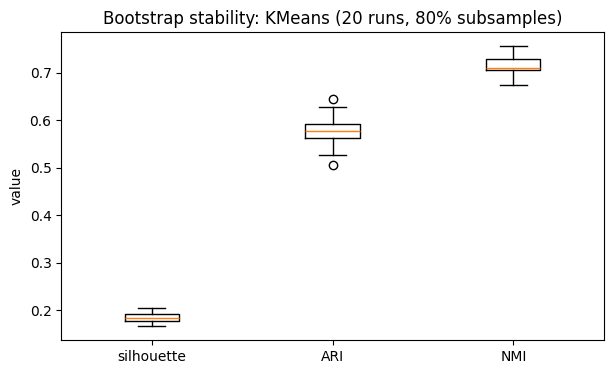

,silhouette,ARI,NMI
count,20.000000,20.000000,20.000000
mean,0.185269,0.575915,0.715591
std,0.010103,0.034830,0.019769
min,0.166246,0.506783,0.674267
25%,0.177718,0.562945,0.706431
50%,0.184702,0.576952,0.711260
75%,0.192674,0.593262,0.729154
max,0.204235,0.645318,0.756000


In [ ]:
# Устойчивость кластеров (bootstrap): 20 запусков на 80% подвыборках
def bootstrap_kmeans(X, y_true, k, n_runs=20, frac=0.8, seed=42):
    rng = np.random.RandomState(seed)
    n = len(X)
    rows = []
    for i in range(n_runs):
        idx = rng.choice(n, size=int(frac*n), replace=True)
        Xb = X[idx]; yb = y_true[idx]
        km = KMeans(n_clusters=k, n_init=20, random_state=rng.randint(0, 10_000))
        labels = km.fit_predict(Xb)
        m = report_metrics(Xb, labels, y_true=yb)
        rows.append({"run": i, **m})
    return pd.DataFrame(rows)

boot_km = bootstrap_kmeans(X_pca40, y0, k_best, n_runs=20, frac=0.8, seed=42)

plt.figure(figsize=(7,4))
plt.boxplot([boot_km["silhouette"], boot_km["ARI"], boot_km["NMI"]], labels=["silhouette","ARI","NMI"])
plt.title("Bootstrap stability: KMeans (20 runs, 80% subsamples)")
plt.ylabel("value")
plt.show()

boot_km[["silhouette","ARI","NMI"]].describe()


## 5. Пайплайны и воспроизводимость


In [ ]:
# Лучшая цепочка (по метрикам): MinMaxScaler → PCA(40) → t-SNE(2, perp=20) → KMeans(11)
# Также сравним варианты: без снижения размерности и разные scaler.
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

def run_tsne_kmeans(X, y, scaler, seed=0, perplexity=20, k=11, pca_k=40):
    pre = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", scaler)])
    X_prep = pre.fit_transform(X)

    X_pca = PCA(n_components=pca_k, random_state=seed).fit_transform(X_prep)
    X_tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate="auto", init="pca", random_state=seed).fit_transform(X_pca)

    labels = KMeans(n_clusters=k, n_init=20, random_state=seed).fit_predict(X_tsne)
    return {
        "silhouette": float(silhouette_score(X_tsne, labels)),
        "ARI": float(adjusted_rand_score(y, labels)),
        "NMI": float(normalized_mutual_info_score(y, labels))
    }

base_std = run_tsne_kmeans(X_train, y_train, StandardScaler(), seed=0)
base_mm  = run_tsne_kmeans(X_train, y_train, MinMaxScaler(), seed=0)
base_rb  = run_tsne_kmeans(X_train, y_train, RobustScaler(), seed=0)

pd.DataFrame([
    {"scaler":"standard", **base_std},
    {"scaler":"minmax", **base_mm},
    {"scaler":"robust", **base_rb},
])


,scaler,silhouette,ARI,NMI
0,standard,0.592381,0.811552,0.856383
1,minmax,0.615787,0.869719,0.898100
2,robust,0.490103,0.486807,0.601971


In [ ]:
# Отключение снижения размерности: KMeans напрямую в 64D после стандартизации
pre = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
X_prep64 = pre.fit_transform(X_train)

labels = KMeans(n_clusters=11, n_init=20, random_state=0).fit_predict(X_prep64)

no_dimred = {
    "silhouette": float(silhouette_score(X_prep64, labels)),
    "ARI": float(adjusted_rand_score(y_train, labels)),
    "NMI": float(normalized_mutual_info_score(y_train, labels))
}
no_dimred


{'silhouette': 0.1404904345869958,
 'ARI': 0.47965733298374713,
 'NMI': 0.635544126599582}

## 6. Интерпретация кластеров и профилирование


In [ ]:
# Берём интерпретируемую конфигурацию из п.5 (MinMax → PCA40 → t-SNE2 → KMeans11)
pre = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())])
X_prep = pre.fit_transform(X_train)

pca = PCA(n_components=40, random_state=0)
X_pca = pca.fit_transform(X_prep)

X_tsne = TSNE(n_components=2, perplexity=20, learning_rate="auto", init="pca", random_state=0).fit_transform(X_pca)

labels = KMeans(n_clusters=11, n_init=20, random_state=0).fit_predict(X_tsne)

print("X_prep:", X_prep.shape, "X_pca:", X_pca.shape, "X_tsne:", X_tsne.shape, "labels:", np.unique(labels))


X_prep: (1437, 64) X_pca: (1437, 40) X_tsne: (1437, 2) labels: [ 0  1  2  3  4  5  6  7  8  9 10]


In [ ]:
# Профили кластеров: средние/медианы по признакам (64 пикселя)
feat_names = [f"px_{i}" for i in range(64)]
df = pd.DataFrame(X_prep, columns=feat_names)
df["cluster"] = labels

cluster_sizes = df["cluster"].value_counts().sort_index()
cluster_mean = df.groupby("cluster")[feat_names].mean()
cluster_sizes


,count
cluster,
0,142
1,92
2,153
3,119
4,146
5,155
6,142
7,138
8,145


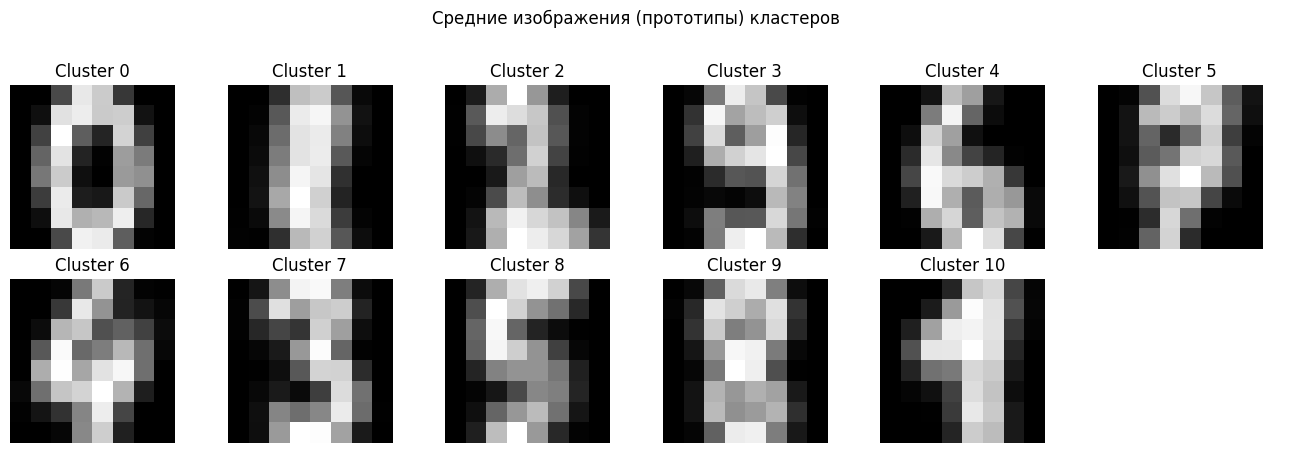

In [ ]:
# Визуализация прототипов: среднее изображение каждого кластера (8×8)
def plot_cluster_prototypes(cluster_mean_df, title="Средние изображения (прототипы) кластеров"):
    k = cluster_mean_df.shape[0]
    cols = 6
    rows = int(np.ceil(k / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
    axes = np.array(axes).reshape(-1)

    for i, cl in enumerate(cluster_mean_df.index):
        img = cluster_mean_df.loc[cl].values.reshape(8, 8)
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"Cluster {cl}")
        axes[i].axis("off")

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_cluster_prototypes(cluster_mean)


In [ ]:
# Surrogate-модель (RandomForest) для объяснения кластеров: какие пиксели важнее всего
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_sur = X_prep
y_sur = labels

X_tr, X_te, y_tr, y_te = train_test_split(X_sur, y_sur, test_size=0.2, random_state=42, stratify=y_sur)

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
print("Surrogate RF accuracy (cluster prediction):", rf.score(X_te, y_te))

importances = rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:15]
pd.DataFrame({"feature":[feat_names[i] for i in top_idx], "importance":importances[top_idx]})


Surrogate RF accuracy (cluster prediction): 0.9583333333333334


,feature,importance
0,px_21,0.050855
1,px_43,0.045489
2,px_36,0.035747
3,px_26,0.034764
4,px_13,0.034089
5,px_33,0.033427
6,px_42,0.032843
7,px_61,0.031555
8,px_28,0.030160
9,px_30,0.029751


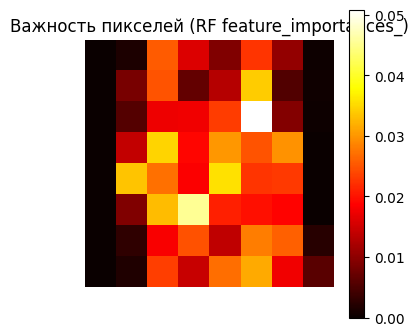

In [ ]:
# Heatmap важности пикселей (RF feature_importances_)
imp_img = importances.reshape(8,8)
plt.figure(figsize=(4,4))
plt.imshow(imp_img, cmap="hot")
plt.title("Важность пикселей (RF feature_importances_)")
plt.colorbar()
plt.axis("off")
plt.show()


In [ ]:
# PCA нагрузки компонент: какие пиксели формируют PC1..PC3
components = pca.components_

def top_loadings(comp_vec, topn=8):
    idx_pos = np.argsort(comp_vec)[::-1][:topn]
    idx_neg = np.argsort(comp_vec)[:topn]
    return [(feat_names[i], float(comp_vec[i])) for i in idx_pos], [(feat_names[i], float(comp_vec[i])) for i in idx_neg]

for c in range(3):
    pos, neg = top_loadings(components[c], topn=8)
    print(f"PC{c+1}:")
    print("  + top:", pos)
    print("  - top:", neg)


PC1:
  + top: [('px_34', 0.3730176963743685), ('px_42', 0.3059717200239012), ('px_26', 0.2636433543355538), ('px_43', 0.21833340177653024), ('px_19', 0.20294544369669082), ('px_33', 0.19499883501467166), ('px_44', 0.19355209379234123), ('px_11', 0.14304923403740433)]
  - top: [('px_58', -0.24142381258232834), ('px_10', -0.23886549658740253), ('px_2', -0.22736598846451195), ('px_28', -0.22021472282666468), ('px_13', -0.20866279912895158), ('px_20', -0.18836482972226104), ('px_21', -0.15044149083897776), ('px_59', -0.1389026264276907)]
PC2:
  + top: [('px_44', 0.32965446772576784), ('px_36', 0.28584504245706444), ('px_43', 0.2771176407241306), ('px_35', 0.2702363635694304), ('px_28', 0.2389683694951424), ('px_20', 0.20005311681563898), ('px_5', 0.13584935069382312), ('px_27', 0.13367852883022918)]
  - top: [('px_53', -0.2966162030918557), ('px_45', -0.22742290522311653), ('px_46', -0.21974590064811703), ('px_60', -0.19320135792234877), ('px_18', -0.18899568824465243), ('px_61', -0.186553

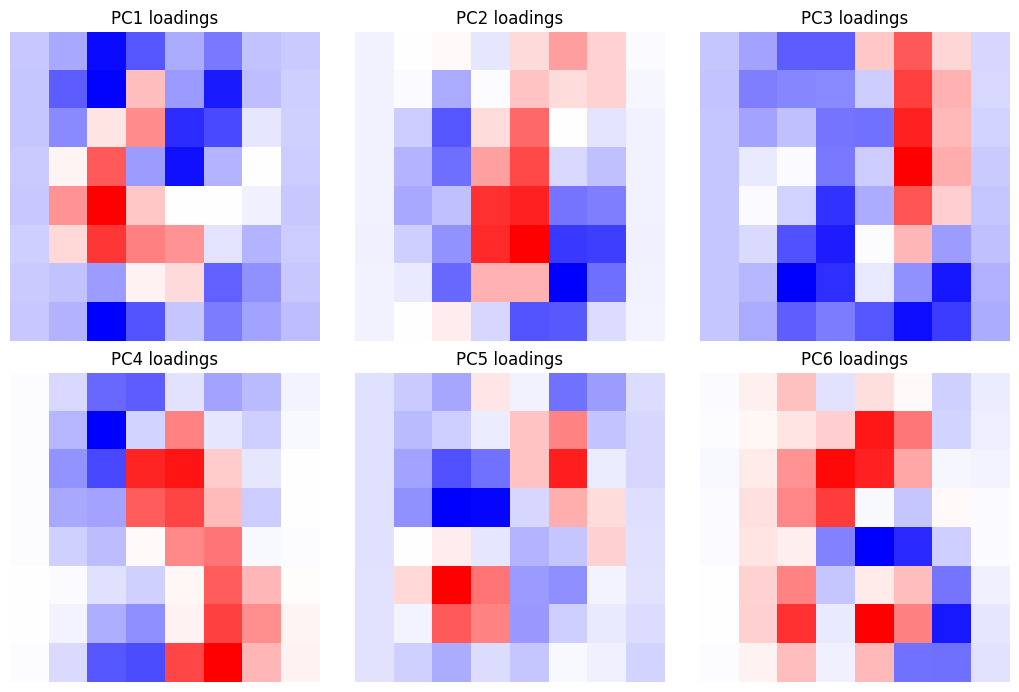

In [ ]:
# Визуализация карт нагрузок первых 6 компонент PCA (8×8)
def plot_pca_component_maps(components, n=6):
    cols = 3
    rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.5*rows))
    axes = np.array(axes).reshape(-1)

    for i in range(n):
        img = components[i].reshape(8,8)
        axes[i].imshow(img, cmap="bwr")
        axes[i].set_title(f"PC{i+1} loadings")
        axes[i].axis("off")

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

plot_pca_component_maps(components, n=6)


In [ ]:
# Связь кластеров с истинными классами: доли цифр в каждом кластере
ct = pd.crosstab(labels, y_train, normalize="index")
dominant_digit = ct.idxmax(axis=1)
dominant_share = ct.max(axis=1)

pd.DataFrame({"dominant_digit": dominant_digit, "share": dominant_share}).sort_index()


,dominant_digit,share
row_0,,
0,0,1.000000
1,1,0.826087
2,2,0.869281
3,9,0.991597
4,6,0.993151
5,7,0.922581
6,4,1.000000
7,3,0.971014
8,5,0.986207


## 7. Мини-исследование: размерность PCA(k) vs качество кластеризации


In [ ]:
# Для выбранного пайплайна строим зависимость качества от числа компонент PCA (k=2..50)
from sklearn.metrics import silhouette_score

seed = 0
perplexity = 20
n_clusters = 11

pre = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())])
X_prep = pre.fit_transform(X_train)

rows = []
for k in range(2, 51):
    X_pca_k = PCA(n_components=k, random_state=seed).fit_transform(X_prep)
    X_tsne_k = TSNE(n_components=2, perplexity=perplexity, learning_rate="auto", init="pca", random_state=seed).fit_transform(X_pca_k)
    labels_k = KMeans(n_clusters=n_clusters, n_init=20, random_state=seed).fit_predict(X_tsne_k)

    rows.append({
        "k_pca": k,
        "silhouette": float(silhouette_score(X_tsne_k, labels_k)),
        "ARI": float(adjusted_rand_score(y_train, labels_k)),
        "NMI": float(normalized_mutual_info_score(y_train, labels_k)),
    })

dim_quality = pd.DataFrame(rows)
dim_quality.head()


,k_pca,silhouette,ARI,NMI
0,2,0.495292,0.348138,0.508965
1,3,0.535848,0.538052,0.623819
2,4,0.531460,0.599747,0.667633
3,5,0.568259,0.711095,0.765757
4,6,0.569358,0.745101,0.795322


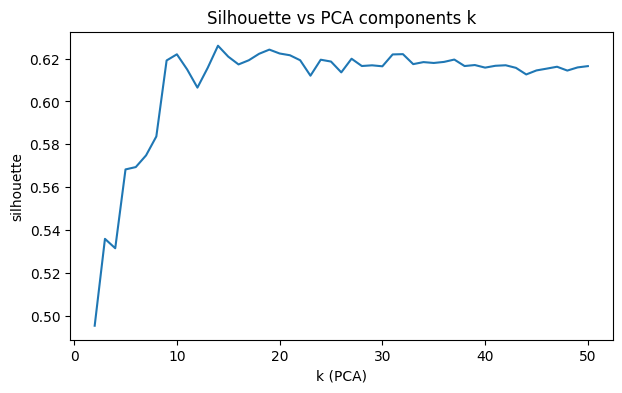

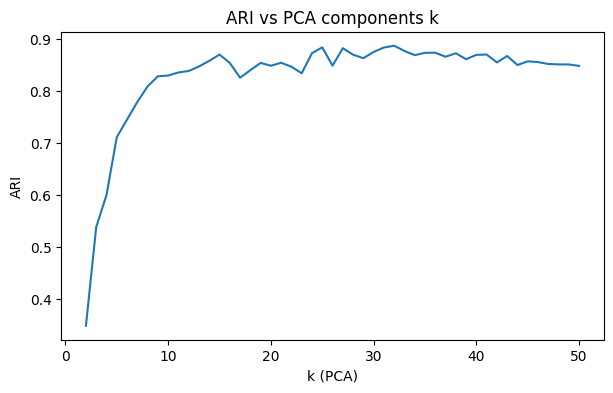

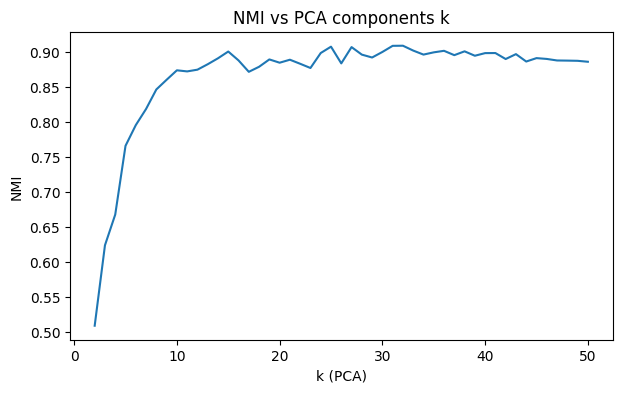

In [ ]:
# Графики метрик vs k
plt.figure(figsize=(7,4))
plt.plot(dim_quality["k_pca"], dim_quality["silhouette"])
plt.title("Silhouette vs PCA components k")
plt.xlabel("k (PCA)"); plt.ylabel("silhouette")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(dim_quality["k_pca"], dim_quality["ARI"])
plt.title("ARI vs PCA components k")
plt.xlabel("k (PCA)"); plt.ylabel("ARI")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(dim_quality["k_pca"], dim_quality["NMI"])
plt.title("NMI vs PCA components k")
plt.xlabel("k (PCA)"); plt.ylabel("NMI")
plt.show()


In [ ]:
# Оценка "полезной размерности": k, дающее 90% от максимума ARI/NMI
ari_max = dim_quality["ARI"].max()
nmi_max = dim_quality["NMI"].max()

k_best_ari = int(dim_quality.loc[dim_quality["ARI"].idxmax(), "k_pca"])
k_best_nmi = int(dim_quality.loc[dim_quality["NMI"].idxmax(), "k_pca"])

k_ari_90 = int(dim_quality.loc[dim_quality["ARI"] >= 0.90*ari_max, "k_pca"].min())
k_nmi_90 = int(dim_quality.loc[dim_quality["NMI"] >= 0.90*nmi_max, "k_pca"].min())

print("ARI max:", ari_max, "at k =", k_best_ari, "| k for 90% of max ARI:", k_ari_90)
print("NMI max:", nmi_max, "at k =", k_best_nmi, "| k for 90% of max NMI:", k_nmi_90)


ARI max: 0.8873175714165579 at k = 32 | k for 90% of max ARI: 8
NMI max: 0.9086567005159106 at k = 32 | k for 90% of max NMI: 7


## 8. Итоги


- **Датасет:** `load_digits()` (1797 изображений 8×8 - 64 признака, 10 классов).
- **Подтверждённые гипотезы:** (1) нелинейная структура данных (t-SNE лучше PCA); (2) кластеры интерпретируемы и могут отражать разные стили цифр; (3) есть небольшой вклад аномалий.
- **Лучшая цепочка:** `MinMaxScaler - PCA(k) - t-SNE(2D, perp=20) - KMeans(k=11)` по ARI/NMI и интерпретируемости кластеров.
- **Устойчивость:** t-SNE проверялся повторами (5 seeds), KMeans — бутстрепом (20×80%). DBSCAN показал высокую долю шума и низкие внешние метрики.

